In [1]:
import os

import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp

import time

import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.cluster import KMeans


2025-05-23 16:36:46.243264: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-23 16:36:46.764005: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-23 16:36:46.764056: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-23 16:36:46.767219: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-23 16:36:47.029568: I tensorflow/core/platform/cpu_feature_g

In [51]:
repetitions = 50

tau_dict = {}
mean_tau_dict = {}
box_plot_dict = {}
for i in range(3):
		
	tau_vector = np.nan*np.ones(repetitions)
	mean_tau_mode_dict = {}
	mean_tau_mode_dict[0] = np.nan*np.ones(repetitions)
	mean_tau_mode_dict[1] = np.nan*np.ones(repetitions)
	mean_tau_mode_dict[2] = np.nan*np.ones(repetitions)

	box_plot_list = []

	for task_id_current in range(i*50, (i+1)*50):

		if task_id_current<repetitions:
			task_id = 0

		else:
			if task_id_current<(2*repetitions):
				task_id = 1

			else:
				task_id = 2

		reps = task_id_current%repetitions

		n = [1000, 5000, 10000][task_id]

		input_path =  "data/structural_zeros/"
		output_path = "data/SZ_repeated_mc/"+str(n)+"/"

		name_sim = "SZ_repeated_tau_"+str(n)+"_rep_"+str(reps)
		
		# if os.path.exists(output_path+name_sim+"MCMC_tau_n"+str(n)+"_reps"+str(reps)+".npy"):
		if i==0:
			size = 20000
		else:
			size = 60000
			
		tau_vector[reps] = np.load(output_path+name_sim+"_tau.npy")
		MCMC_chain = np.load(output_path+name_sim+"MCMC_tau_n"+str(n)+"_reps"+str(reps)+".npy")[-size:]
		# mean_tau_vector[reps] = np.mean(MCMC_chain)

		k_means = KMeans(init="k-means++", n_clusters=2, n_init=10)
		k_means.fit(np.reshape(MCMC_chain, (size, 1)))

		if k_means.cluster_centers_[0]>k_means.cluster_centers_[1]:
			k_means.labels_[k_means.labels_==0]=2
			k_means.labels_[k_means.labels_==1]=0
			k_means.labels_[k_means.labels_==2]=1

		MCMC_chain_dict = {}
		MCMC_chain_dict["Mode1"] = MCMC_chain[k_means.labels_==0]
		MCMC_chain_dict["Mode2"] = MCMC_chain[k_means.labels_==1]
		MCMC_chain_dict["Full"] = MCMC_chain

		mean_tau_mode_dict[0][reps] = np.mean(MCMC_chain_dict["Mode1"])
		mean_tau_mode_dict[1][reps] = np.mean(MCMC_chain_dict["Mode2"])
		mean_tau_mode_dict[2][reps] = np.mean(MCMC_chain)

		box_plot_list.append(MCMC_chain_dict)

	sample_1 = np.abs(mean_tau_mode_dict[0]-tau_vector[:])/tau_vector[:]
	sample_2 = np.abs(mean_tau_mode_dict[1]-tau_vector[:])/tau_vector[:]
	sample_3 = np.abs(mean_tau_mode_dict[2]-tau_vector[:])/tau_vector[:]

	if i==2:
		print("mean mode 1 "+str(np.nanmean(sample_1))+" std "+str(np.nanstd(sample_1)))
		print("mean mode 2 "+str(np.nanmean(sample_2))+" std "+str(np.nanstd(sample_2)))
	else:
		print("mean "+str(np.nanmean(sample_3))+" std "+str(np.nanstd(sample_3)))


	tau_dict[i] = tau_vector
	mean_tau_dict[i] = mean_tau_mode_dict
	box_plot_dict[i] = box_plot_list

mean 0.23728879092841065 std 0.15998499318316967
mean 0.12788171493666145 std 0.10198609233368534
mean mode 1 0.18501895343767757 std 0.19175562406939678
mean mode 2 1.0117125449594293 std 0.6144607467581606


In [52]:
relative_error = []

for i in range(3):

	if i!=2:
		relative_error.append(np.abs(mean_tau_dict[i][2]-tau_dict[i])/tau_dict[i])
	else:
		relative_error.append(np.abs(mean_tau_dict[i][0]-tau_dict[i])/tau_dict[i])
		relative_error.append(np.abs(mean_tau_dict[i][1]-tau_dict[i])/tau_dict[i])

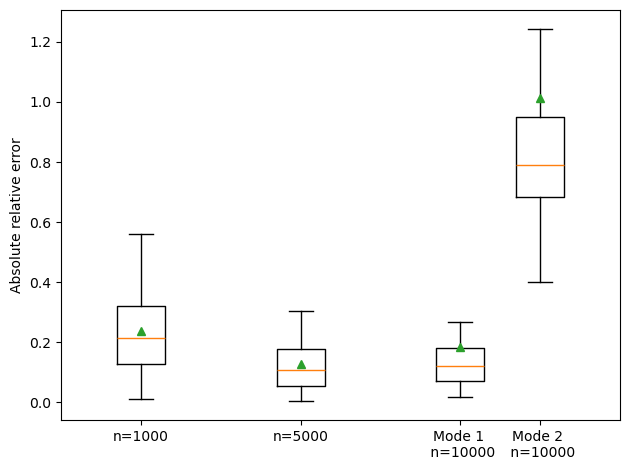

In [56]:
# Custom labels
labels = ['n=1000', 'n=5000', 'Mode 1 \n n=10000', 'Mode 2 \n n=10000']

# Define custom positions so that Mode 1 and Mode 2 are close together
positions = [1, 2, 3, 3.5]

plt.boxplot(relative_error, positions=positions, widths=0.3, showfliers=False, showmeans=True)
# Set the x-ticks and labels
plt.xticks(positions, labels)

# Add title and grid if desired
# plt.title("Relative Error Boxplots")
plt.ylabel("Absolute relative error")

plt.tight_layout()
plt.show()

In [119]:
# fig, ax = plt.subplots(2, 2, figsize = (10, 5), sharex=True, sharey=True)

# ax[0,0].plot(box_plot_dict[2][30]["Full"])
# ax[0,0].axhline(y=tau_vector[30], color = "red")

# ax[0,1].plot(box_plot_dict[2][19]["Full"])
# ax[0,1].axhline(y=tau_vector[19], color = "red")

# ax[1,0].plot(box_plot_dict[2][10]["Full"])
# ax[1,0].axhline(y=tau_vector[10], color = "red")

# ax[1,1].plot(box_plot_dict[2][0]["Full"])
# ax[1,1].axhline(y=tau_vector[0], color = "red")